In [1]:
import torch
import torch.nn as nn
from tqdm import tqdm

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv_path(x)
        out += self.shortcut(x) 
        return torch.relu(out)

In [39]:
class SimpleResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, rgb_channel=3):
        super(SimpleResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(rgb_channel, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        # self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        # out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        return self.fc(out)

In [42]:
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_data = CIFAR10(root='data', train=True, transform=transform_train, download=True)
trainloader = DataLoader(train_data, batch_size=128, shuffle=True)
# test_data = CIFAR10(root='data', train=False, transform=transforms.ToTensor(), download=True)

model = SimpleResNet(ResidualBlock, [2, 2, 2]).to(device)
learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

cuda


In [43]:
def train(model, criterion, optimizer, device, data, epochs=5):
    model.train()

    pbar = tqdm(range(epochs), total=epochs)
    
    for epoch in pbar:
        pbar.set_description(f"Epoch [{epoch + 1}/{epochs}]")
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(data):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            if i % 100 == 99:
                print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}')
                running_loss = 0.0

train(model, criterion, optimizer, device, trainloader, epochs=2)
    

Epoch [1/2]:   0%|          | 0/2 [00:00<?, ?it/s]

[Epoch 1, Batch 100] Loss: 1.731
[Epoch 1, Batch 200] Loss: 1.429
[Epoch 1, Batch 300] Loss: 1.304


Epoch [2/2]:  50%|█████     | 1/2 [00:06<00:06,  6.63s/it]

[Epoch 2, Batch 100] Loss: 1.127
[Epoch 2, Batch 200] Loss: 1.091
[Epoch 2, Batch 300] Loss: 1.011


Epoch [2/2]: 100%|██████████| 2/2 [00:13<00:00,  6.61s/it]


In [44]:
def test(model, criterion, optimizer, device, data):

    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in data:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')

transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(test_data, batch_size=128, shuffle=False)
test(model, criterion, optimizer, device, testloader)

Accuracy: 51.31%


In [45]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total: {total_params:,}")

# 如果只想看需要训练的参数（排除冻结层）
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable_params:,}")

Total: 676,682
Trainable: 676,682


In [3]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset
from PIL import Image

from torch.utils.data import DataLoader
import torch.optim as optim
import torchvision.transforms as transforms

import seaborn as sns
from sklearn.metrics import confusion_matrix

class SignLanguageMNIST(Dataset):
    def __init__(self, csv_file, transform=None):
        data = pd.read_csv(csv_file)
        self.labels = np.array(data.iloc[:, 0])
        self.images = np.array(data.iloc[:, 1:]).reshape(-1, 28, 28).astype(np.uint8)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        from PIL import Image
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),     
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)), # 随机缩放裁剪
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # 亮度对比度
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = SignLanguageMNIST('./data/sign/sign_mnist_train.csv', transform=transform_train)
test_data = SignLanguageMNIST('./data/sign/sign_mnist_test.csv', transform=transform_test)

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv_path(x)
        out += self.shortcut(x) 
        return torch.relu(out)

In [10]:
class SimpleResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, rgb_channel=3):
        super(SimpleResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(rgb_channel, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        # self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        # out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        return self.fc(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [12]:
def train(model, criterion, optimizer, device, data, epochs=5):
    model.train()

    pbar = tqdm(range(epochs), total=epochs)
    
    for epoch in pbar:
        pbar.set_description(f"Epoch [{epoch + 1}/{epochs}]")
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(data):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            if i % 100 == 99:
                print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}')
                running_loss = 0.0

def test(model, criterion, optimizer, device, data):

    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in data:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')

transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])


In [20]:

sign_model = SimpleResNet(ResidualBlock, [2, 2], num_classes=25, rgb_channel=1).to(device)
learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(sign_model.parameters(), lr=learning_rate)

train_loader_sign = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader_sign = DataLoader(test_data, batch_size=128, shuffle=False)

sample_img, _ = next(iter(train_loader_sign))
print(f"Data shape: {sample_img.shape}")

train(sign_model, criterion, optimizer, device, train_loader_sign, epochs=2)
test(sign_model, criterion, optimizer, device, test_loader_sign)


Data shape: torch.Size([128, 1, 32, 32])


Epoch [1/2]:   0%|          | 0/2 [00:00<?, ?it/s]

[Epoch 1, Batch 100] Loss: 2.159
[Epoch 1, Batch 200] Loss: 0.811


Epoch [2/2]:  50%|█████     | 1/2 [00:14<00:14, 14.45s/it]

[Epoch 2, Batch 100] Loss: 0.259
[Epoch 2, Batch 200] Loss: 0.121


Epoch [2/2]: 100%|██████████| 2/2 [00:29<00:00, 14.52s/it]


Accuracy: 97.62%


In [21]:
total_params = sum(p.numel() for p in sign_model.parameters())
print(f"Total: {total_params:,}")

# 如果只想看需要训练的参数（排除冻结层）
trainable_params = sum(p.numel() for p in sign_model.parameters() if p.requires_grad)
print(f"Trainable: {trainable_params:,}")

Total: 677,465
Trainable: 677,465


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import string


def get_label_char(label):
    return chr(ord('A') + label)

def visualize_and_stats(model, device, loader):
    model.eval()
    correct_samples = []
    incorrect_samples = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            for i in range(len(labels)):
                img = images[i].cpu().squeeze()
                img = img * 0.5 + 0.5 
                
                label = labels[i].item()
                pred = preds[i].item()

                if label == pred and len(correct_samples) < 10:
                    correct_samples.append((img, label, pred))
                elif label != pred and len(incorrect_samples) < 10:
                    incorrect_samples.append((img, label, pred))
            
            # 收集足够数据后停止
            if len(correct_samples) >= 10 and len(incorrect_samples) >= 10 and len(all_labels) > 5000:
                break

    # --- 1. 画图：2 * 10 布局 ---
    fig, axes = plt.subplots(2, 10, figsize=(20, 7))
    
    # 第一行：正确分类 (显示字母)
    for i in range(10):
        img, label, pred = correct_samples[i]
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"Correct: {get_label_char(label)}")
        axes[0, i].axis('off')

    # 第二行：错误分类 (显示字母)
    for i in range(10):
        if i < len(incorrect_samples):
            img, label, pred = incorrect_samples[i]
            axes[1, i].imshow(img, cmap='gray')
            axes[1, i].set_title(f"GT:{get_label_char(label)}\nPredict:{get_label_char(pred)}", color='red')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('pred.png')
    plt.show()

    # --- 2. 混淆矩阵 (坐标轴使用字母) ---
    # 获取数据中出现的所有唯一标签，并转为字母
    unique_labels = sorted(list(set(all_labels)))
    tick_labels = [get_label_char(l) for l in unique_labels]

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=tick_labels, yticklabels=tick_labels)
    plt.xlabel('Predicted Letter')
    plt.ylabel('Actual Letter')
    plt.title('Confusion Matrix')
    plt.savefig('confusion.png')
    plt.show()


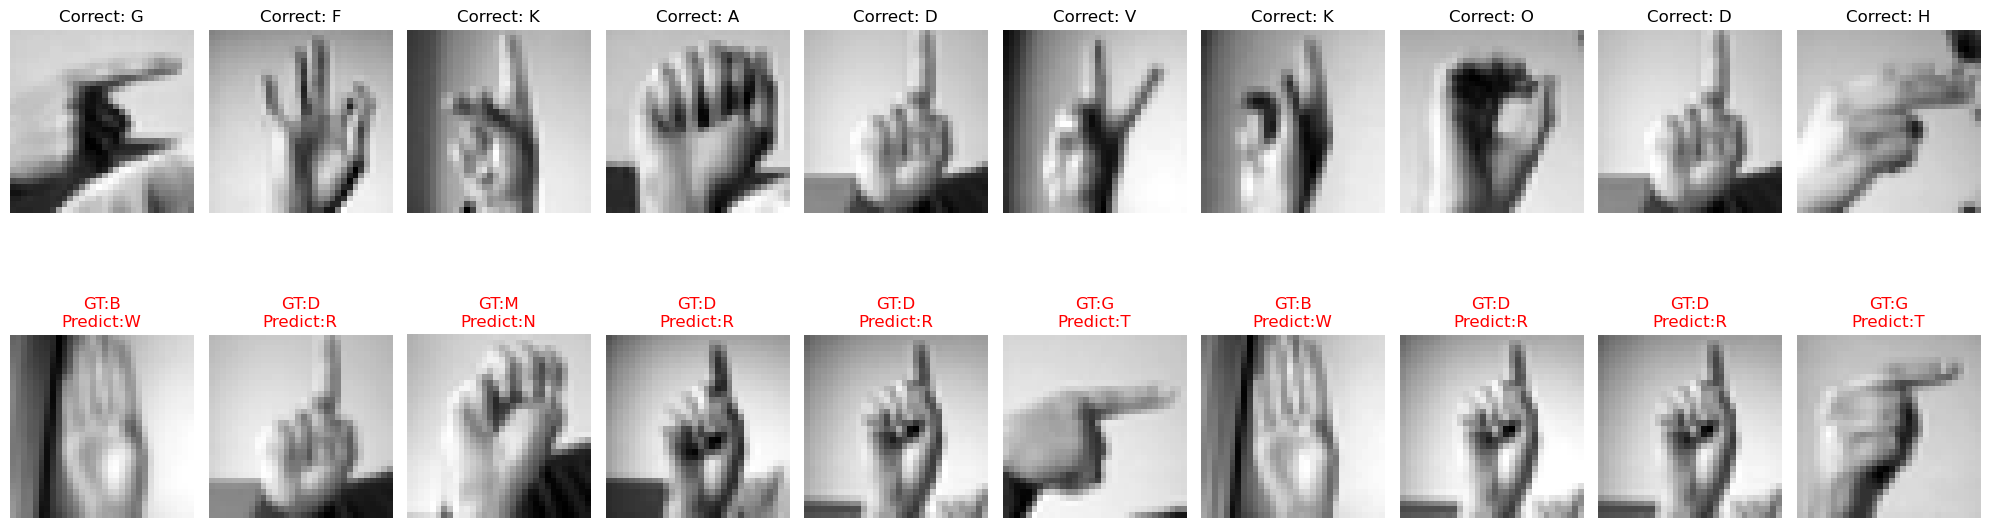

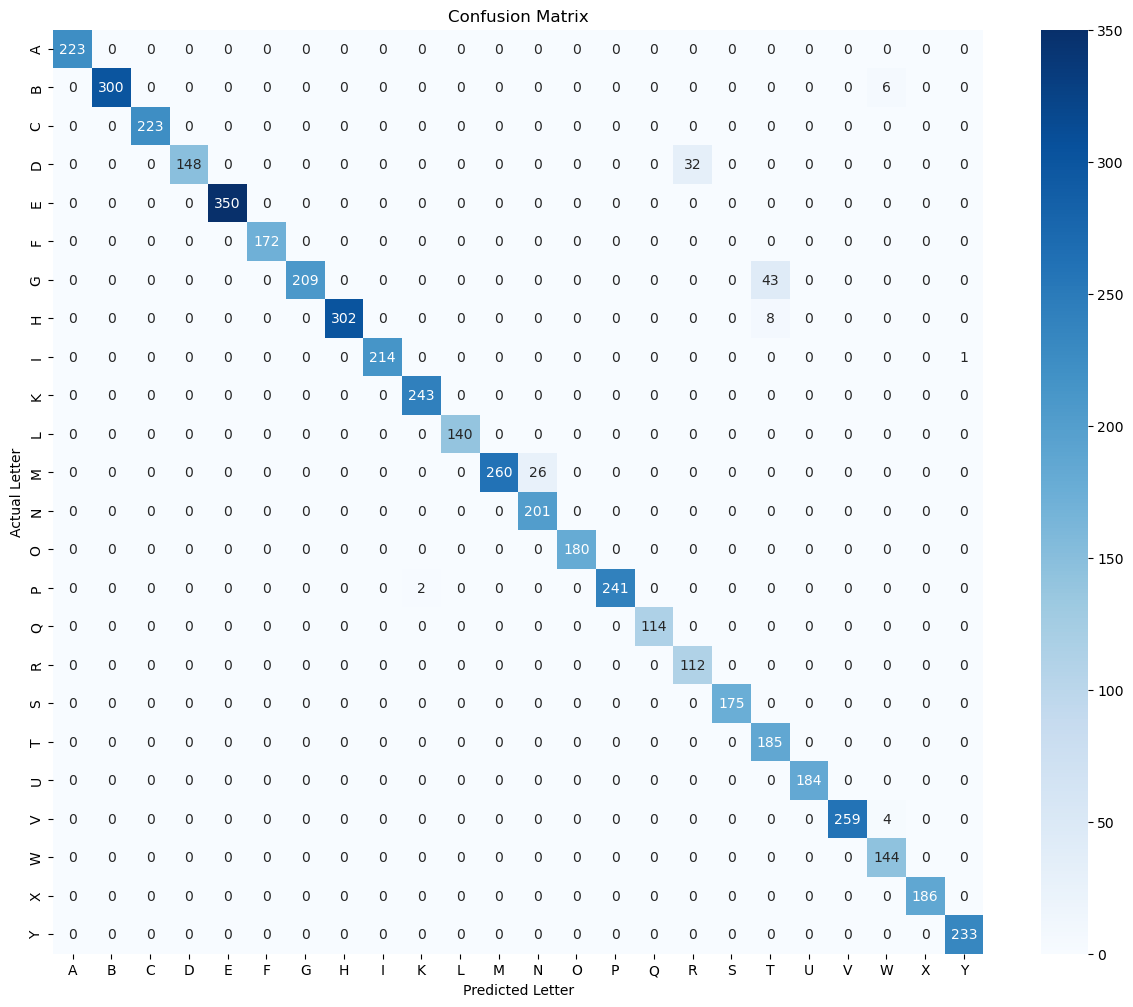

In [31]:
visualize_and_stats(sign_model, device, test_loader_sign)